# DAY 73 — K-Means Clustering & Elbow Method

Practical implementation using Scikit-Learn.

## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


## 2. Create Sample Unlabeled Data

In [3]:
X, _ = make_blobs(n_samples=500, centers=4, cluster_std=1.2, random_state=42)
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df.head()


,Feature_1,Feature_2
0,-7.459200,6.479711
1,-10.115891,-6.945263
2,7.267642,1.003212
3,-2.979727,7.258068
4,-5.438170,-7.369800


## 3. Visualize the Data

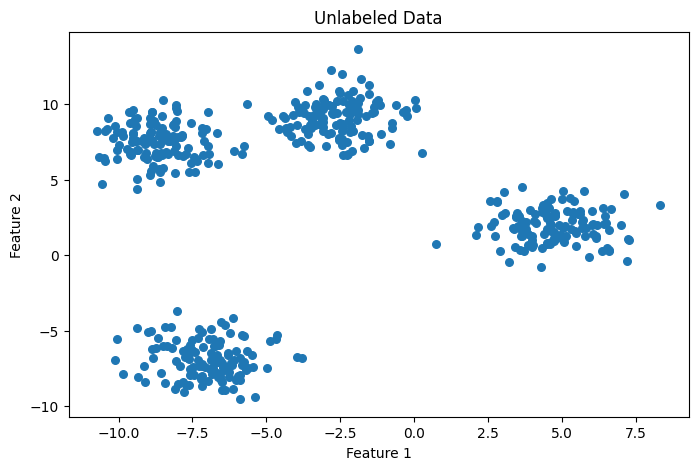

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Feature_1'], df['Feature_2'], s=30)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Unlabeled Data')
plt.show()


## 4. Feature Scaling

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 5. Elbow Method

In [6]:
wcss = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

print(wcss)


[999.9999999999995, 526.8846593423641, 125.42805919372162, 40.84677702589178, 36.34477780476782, 32.48594654811544, 28.721458140798845, 25.387609855358495, 23.347192089684974, 21.225522304955717]


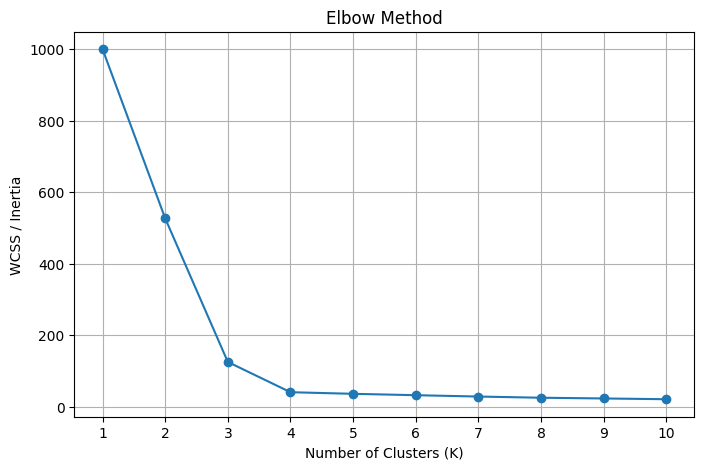

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.title('Elbow Method')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


## 6. Train the Final K-Means Model

For this synthetic dataset, K=4 is used for the demonstration.

In [8]:
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
labels = kmeans.fit_predict(X_scaled)
df['Cluster'] = labels


## 7. Inspect Clusters, Centroids and Inertia

In [9]:
print('Cluster Centers:')
print(kmeans.cluster_centers_)
print('\nInertia:', kmeans.inertia_)
print('\nFirst 10 labels:')
print(labels[:10])


Cluster Centers:
[[ 1.530125   -0.15455934]
 [-0.99037523  0.71941932]
 [-0.68446254 -1.53954638]
 [ 0.14471277  0.97468641]]

Inertia: 40.84677702589178

First 10 labels:
[1 2 0 3 2 2 1 2 0 2]


## 8. Visualize K-Means Clusters

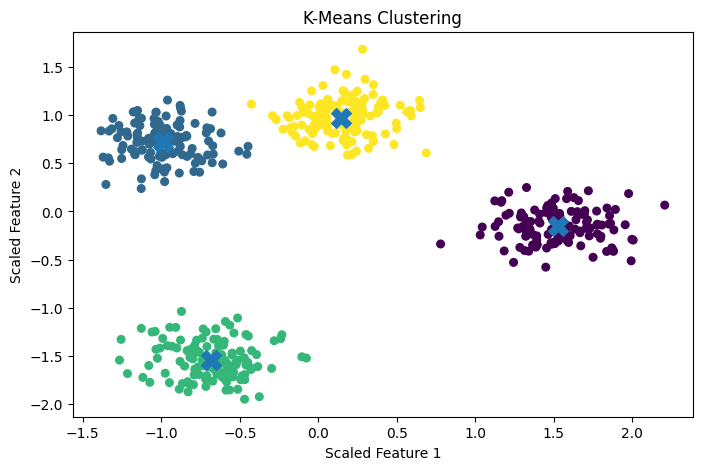

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, s=30)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, marker='X')
plt.xlabel('Scaled Feature 1')
plt.ylabel('Scaled Feature 2')
plt.title('K-Means Clustering')
plt.show()


## 9. Silhouette Score

In [11]:
score = silhouette_score(X_scaled, labels)
print('Silhouette Score:', score)


Silhouette Score: 0.755747194151021


## 10. Predict a New Point

In [12]:
new_point = np.array([[1.0, 1.0]])
new_point_scaled = scaler.transform(new_point)
predicted_cluster = kmeans.predict(new_point_scaled)
print('Predicted Cluster:', predicted_cluster[0])


Predicted Cluster: 0


## 11. Useful K-Means Attributes

In [13]:
print('Cluster Centers:')
print(kmeans.cluster_centers_)
print('\nLabels:')
print(kmeans.labels_[:20])
print('\nInertia:')
print(kmeans.inertia_)


Cluster Centers:
[[ 1.530125   -0.15455934]
 [-0.99037523  0.71941932]
 [-0.68446254 -1.53954638]
 [ 0.14471277  0.97468641]]

Labels:
[1 2 0 3 2 2 1 2 0 2 0 3 0 3 2 0 3 1 1 3]

Inertia:
40.84677702589178
